# Demo

This is a A **demonstration** script for the ECLYPSE network simulator extension.

It sets up an IoT and Core Network topology, defines application traffic flows, and measures the end-to-end packet delays to demonstrate the emergence of network bottlenecks and routing performance under specific traffic loads.

**Network Topology**

The infrastructure is composed of the following nodes and connections:
Access Links

- Sensor → Gateway (100 Mbps, 1 km)
- SensorX → Gateway (200 Mbps, 1 km)
- SensorY → R1 (200 Mbps, 1 km)

**Core Network Links**

- Gateway → R1 (50 Mbps, 5 km)
- Gateway → R2 (50 Mbps, 5 km)
- R1 → R2 (50 Mbps, 2 km)
- R1 → R3 (50 Mbps, 10 km)
- R2 → R3 (50 Mbps, 10 km)

**Bottleneck Link**
- R3 → Cloud (10 Mbps, 50 km)


**Application & Traffic Flows**

A `NetworkApplication` called VideoApp simulates a video streaming scenario. It maps components to the infrastructure using a StaticStrategy:

- **Sensor1** (placed on Sensor) → Cloud1 (placed on Cloud)

- **SensorX1** (placed on SensorX) → Cloud1 (placed on Cloud)

- **SensorY1** (placed on SensorY) → Cloud1 (placed on Cloud)

Each flow generates traffic towards the Cloud component with a packet size of 1500 bytes and an average of 10 packets per step, highlighting how concurrent streams converge into the 10 Mbps bottleneck link (R3 → Cloud).
Simulation Configuration

The simulation runs with the following parameters:

- **Duration**: 11 steps (max_steps=11), with each step occurring every 500 ms.
- **Execution Events**: Implements PacketGenerationEvent and RoutingEvent (step duration: 0.5 ms).
- **Metrics & Output**: Captures data via RoutingMetric and saves the results in JSON format inside the ./results directory using a Pandas backend.

In [1]:
from eclypse.simulation.config import SimulationConfig
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
from eclypse.network import (
                            Network,
                            NetworkApplication,
                            PacketGenerationEvent,
                            RoutingEvent,
                            RoutingMetric
                        )

from eclypse.simulation import Simulation
from eclypse.placement.strategies import StaticStrategy

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

# Add real resources to the hosts
infra.add_host("Sensor", processing_time=0.0001, cpu=2, ram=4)
infra.add_host("SensorX", processing_time=0.0001, cpu=2, ram=4)
infra.add_host("SensorY", processing_time=0.0001, cpu=2, ram=4)

# The constructor of the router class put 0 on cpu and ram automcatically
infra.add_router("Gateway", processing_time=0.0001)
infra.add_router("R1", processing_time=0.0001)
infra.add_router("R2", processing_time=0.0001)
infra.add_router("R3", processing_time=0.0001)

infra.add_host("Cloud", processing_time=0.0001, cpu=16, ram=32)

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1, max_queue_size=100)
# Access Link (SensorX -> Gateway): 200 Mbps, 1 km
infra.add_edge("SensorX", "Gateway", bandwidth_mbps=200, length_km=1, max_queue_size=100)
# Access Link (SensorY -> R1): 200 Mbps, 1 km
infra.add_edge("SensorY", "R1", bandwidth_mbps=200, length_km=1, max_queue_size=100)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5, max_queue_size=100)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5, max_queue_size=100)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2, max_queue_size=100)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10, max_queue_size=100)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10, max_queue_size=100)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50, max_queue_size=100)


print("2. Setting up Application (Video Stream)...")
app = NetworkApplication("VideoApp")

app.add_node("Sensor1", cpu=1, ram=1, gpu=0, storage=0, availability=0.0)
app.add_node("SensorX1", cpu=1, ram=1, gpu=0, storage=0, availability=0.0)
app.add_node("SensorY1", cpu=1, ram=1, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=10, ram=8, gpu=0, storage=0, availability=0.0)

app.add_edge("Sensor1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )


app.add_edge("SensorX1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )

app.add_edge("SensorY1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )

packet_event = PacketGenerationEvent()
execution_event = RoutingEvent(step_duration_s=0.0005)
reporting_metric = RoutingMetric()

sim_config = SimulationConfig(
    seed=42,
    max_steps=11,
    step_every_ms=500,
    path="./results",
    events=[packet_event, execution_event, reporting_metric],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False,
    log_level="DEBUG"
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

# Use Static strategy for placement
strategy = StaticStrategy({
    "Sensor1": "Sensor",
    "SensorX1": "SensorX",
    "SensorY1": "SensorY",
    "Cloud1": "Cloud"
})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
2. Setting up Application (Video Stream)...
09:42:15.256 | INFO | VideoApp - Added flow Sensor1->Cloud1, 10 pkt/step (avg), size 1500B
09:42:15.256 | INFO | VideoApp - Added flow SensorX1->Cloud1, 10 pkt/step (avg), size 1500B
09:42:15.257 | INFO | VideoApp - Added flow SensorY1->Cloud1, 10 pkt/step (avg), size 1500B
3. Initializing Simulation...
09:42:15.631 | DEBUG | Simulation - Registered application | app=VideoApp | remote=False
09:42:15.632 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=results | remote=False | step_every_ms=500 | max_steps=11 | seed=42 | report_format=json | report_backend=pandas | log_level=DEBUG | log_to_file=False | include_default_metrics=False
09:42:15.633 | DEBUG | Simulation - Event triggered | name=enact | triggers=1
09:42:15.633 | ECLYPSE | Simulation - Simulation started.
09:42:15.639 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor',

09:42:20.663 | DEBUG | IoT_Network - Packet 265 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.663 | DEBUG | IoT_Network - Packet 266 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.663 | DEBUG | IoT_Network - Packet 267 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.663 | DEBUG | IoT_Network - Packet 248 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.663 | DEBUG | IoT_Network - Packet 249 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.663 | DEBUG | IoT_Network - Packet 250 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)


09:42:20.663 | DEBUG | IoT_Network - Packet 251 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.664 | DEBUG | IoT_Network - Packet 252 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.664 | DEBUG | IoT_Network - Packet 253 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.664 | DEBUG | IoT_Network - Packet 254 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.664 | DEBUG | IoT_Network - Packet 255 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.664 | DEBUG | IoT_Network - Packet 256 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.664 | DEBUG | IoT_Network - Packet 257 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.664 | DEBUG | IoT_Network - Packet 258 DROPPED at Gateway: Queue full on link Gateway->R2 (Limit: 100)
09:42:20.664 | INFO | IoT_Network - R1 order: [268 (SensorY), 269 (SensorY), 270 (SensorY), 271 (SensorY

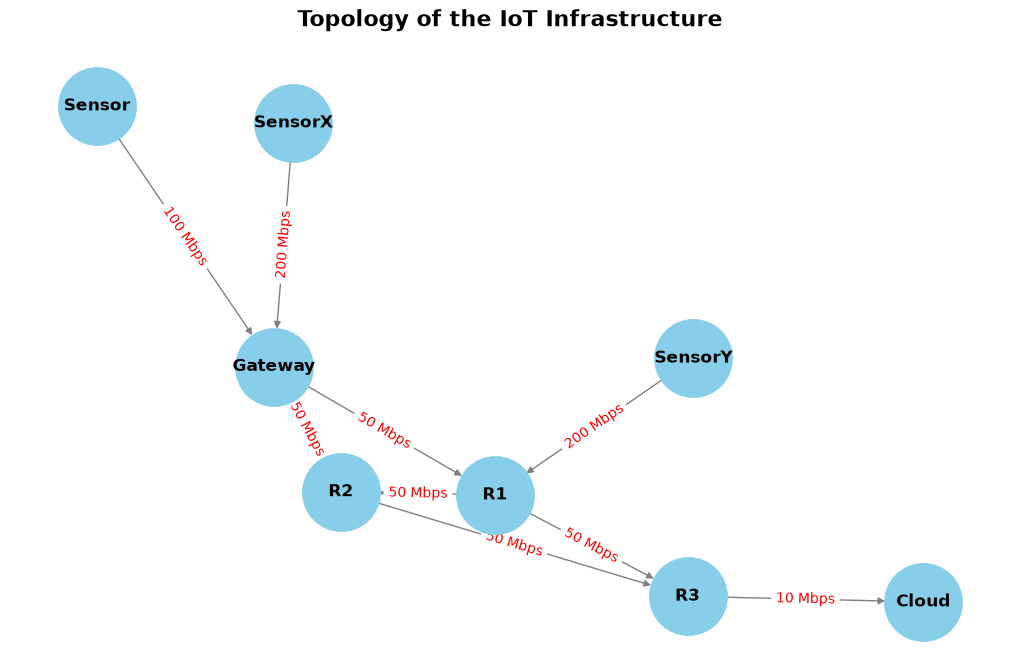

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a NetworkX graph from the infrastructure
plt.figure(figsize=(10, 6))

pos_base = nx.kamada_kawai_layout(infra)
pos = nx.spring_layout(infra, pos=pos_base, k=1.0, iterations=50, seed=42)
# Draw the network with custom styling
nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=3000,
    font_size=12,
    font_weight='bold',
    edge_color='gray',
    linewidths=2
)

# print the bandwidth on the edges using the 'bandwidth_mbps' attribute
edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    # add "Mbps" to the bandwidth values for better readability
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of the IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')  # Hide axes for better visualization
plt.show()

In [4]:
import pandas as pd
import json
import os

# Load the JSONL file and extract metrics
json_path = "./results/json/application.jsonl"
records = []

if not os.path.exists(json_path):
    raise FileNotFoundError(f"File {json_path} not found")

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

if not records:
    raise ValueError("The JSONL file is empty or does not contain valid metrics.")

df_raw = pd.DataFrame(records)

# Extract Step, Packet_ID, Hop_ID and Field from the metric naming convention
extracted = df_raw['metric'].str.extract(r'step_(\d+)_pkt_(\d+)_hop_(\d+)_(.*)')

df_raw['Step'] = extracted[0].astype(float)
df_raw['Packet_ID'] = extracted[1].astype(float)
df_raw['Hop_ID'] = extracted[2].astype(float)
df_raw['Field'] = extracted[3]

# Filter the DataFrame to keep only rows that have valid Packet_IDs (i.e., those that match the expected pattern)
df_hops = df_raw.dropna(subset=['Packet_ID']).copy()

# Convert the relevant columns to integers
df_hops['Step'] = df_hops['Step'].astype(int)
df_hops['Packet_ID'] = df_hops['Packet_ID'].astype(int)
df_hops['Hop_ID'] = df_hops['Hop_ID'].astype(int)

# Group by Step, Packet_ID, and Hop_ID
df_pivot = df_hops.pivot_table(
    index=['Step', 'Packet_ID', 'Hop_ID'],
    columns='Field',
    values='val',
    aggfunc='first'
).reset_index()

# Conversion into numeric types for the relevant columns
numeric_cols = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col], errors='coerce')

df_pivot['queue_length'] = pd.to_numeric(df_pivot.get('queue_length', 0)).fillna(0).astype(int)

# management of 'dropped' field
if 'dropped' in df_pivot.columns:
    # Substitutes NaN values with False (in case there are old records without the field)
    df_pivot['dropped'] = df_pivot['dropped'].fillna(False)
    # Ensures conversion to boolean (in the JSON, Pandas might read it as the string "True")
    df_pivot['dropped'] = df_pivot['dropped'].apply(
        lambda x: str(x).lower() == 'true' if isinstance(x, str) else bool(x)
    )
else:
    df_pivot['dropped'] = False
# -------------------------------------------------------------

# Security check: if the 'hop' string is not in the JSON due to ECLYPSE limitations, add a default value
if 'hop' not in df_pivot.columns:
    df_pivot['hop'] = "Route N/A"

# Print the chronological log of hops
print("\n--- Chronological Log of Hops ---")

# Order by the absolute arrival timestamp
df_log = df_pivot.sort_values('arrival_at_next').dropna(subset=['arrival_at_next'])

for _, row in df_log.iterrows():
    # Extract the route name from the 'hop' field, which is expected to be a string like "Sensor->Gateway"
    route_name = str(row['hop'])

    drop_alert = " ⚠️ [DROPPED]" if row['dropped'] else ""

    print(f"[Arrival: {row['arrival_at_next']:7.4f} ms] | "
          f"Step: {row['Step']:<3} | "
          f"Pkt: {row['Packet_ID']:<3} (Hop {row['Hop_ID']}) | "
          f"Route: {route_name:<15} | "
          f"Queue: {row['queue_length']:>2} pkt | "
          f"Delay Queue: {row['queue_ms']:6.4f} ms{drop_alert}")


--- Chronological Log of Hops ---
[Arrival:  0.6650 ms] | Step: 1   | Pkt: 19  (Hop 1) | Route: SensorY->R1     | Queue:  0 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.6650 ms] | Step: 1   | Pkt: 13  (Hop 1) | Route: SensorX->Gateway | Queue:  0 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.7250 ms] | Step: 1   | Pkt: 1   (Hop 1) | Route: Sensor->Gateway | Queue:  0 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.7250 ms] | Step: 1   | Pkt: 14  (Hop 1) | Route: SensorX->Gateway | Queue:  1 pkt | Delay Queue: 0.0600 ms
[Arrival:  0.7250 ms] | Step: 1   | Pkt: 20  (Hop 1) | Route: SensorY->R1     | Queue:  1 pkt | Delay Queue: 0.0600 ms
[Arrival:  0.7850 ms] | Step: 1   | Pkt: 15  (Hop 1) | Route: SensorX->Gateway | Queue:  2 pkt | Delay Queue: 0.1200 ms
[Arrival:  0.7850 ms] | Step: 1   | Pkt: 21  (Hop 1) | Route: SensorY->R1     | Queue:  2 pkt | Delay Queue: 0.1200 ms
[Arrival:  0.8450 ms] | Step: 1   | Pkt: 2   (Hop 1) | Route: Sensor->Gateway | Queue:  1 pkt | Delay Queue: 0.1200 ms
[Arrival: 

In [5]:
import pandas as pd
import json
import re

results = []
with open('./results/json/application.jsonl', 'r') as f:
    for line in f:
        log = json.loads(line)
        if log.get('event_name') == 'step' and 'data' in log:
            for item in log['data']:
                # Search only for metric lists (es: ["VideoApp", "step_1_pkt_1_hop_1_queue_ms", 0.0])
                if isinstance(item, list) and len(item) == 3:
                    metric_name = item[1]
                    if metric_name and "hop" in metric_name:
                        # Extract the packet ID and type of metric via regex
                        match = re.search(r'pkt_(\d+)_hop_(\d+)_(.*)_ms', metric_name)
                        if match:
                            results.append({
                                'pkt_id': int(match.group(1)),
                                'hop': int(match.group(2)),
                                'metric': match.group(3),
                                'value': item[2]
                            })

# Transformation into a DataFrame
df = pd.DataFrame(results)

# Pivoting to have the 4 delays as columns
df_pivot = df.pivot_table(index=['pkt_id', 'hop'], columns='metric', values='value').reset_index()

# Analysis of a representative packet
pkt_id = 1
pkt_data = df_pivot[df_pivot['pkt_id'] == pkt_id].copy()

# Visualization of the data for each hop
print(f"Decomposition of the delays for packet {pkt_id}:")
print(pkt_data[['hop', 'processing', 'queue', 'transmission', 'propagation']])

# Total E2E delay calculation
e2e = pkt_data[['processing', 'queue', 'transmission', 'propagation']].sum()
print("\n--- Total E2E  delay(ms) ---")
print(e2e)

Decomposition of the delays for packet 1:
metric  hop  processing  queue  transmission  propagation
0         1         0.1   0.00          0.12        0.005
1         2         0.1   0.48          0.24        0.025
2         3         0.1   0.48          0.24        0.050
3         4         0.1  20.40          1.20        0.250

--- Total E2E  delay(ms) ---
metric
processing       0.40
queue           21.36
transmission     1.80
propagation      0.33
dtype: float64


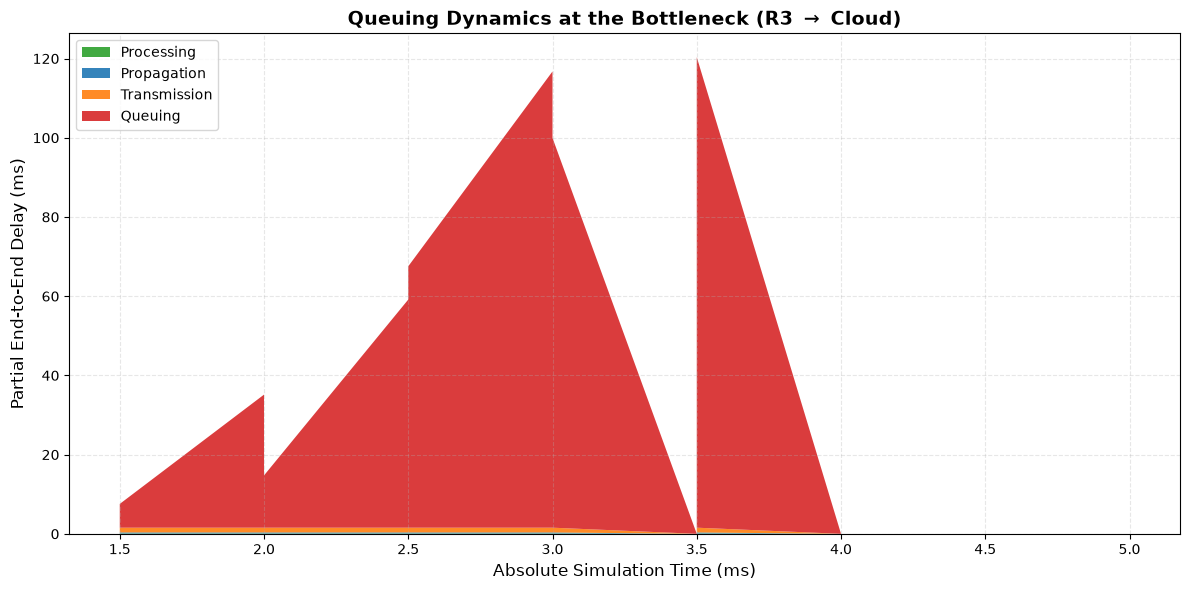

In [6]:
import pandas as pd
import json
import re
import matplotlib.pyplot as plt
import numpy as np

def load_and_process_data(json_path: str, bottleneck_hop: str = 'R3->Cloud'):
    """
    Load logs from the JSONL file, convert metrics to a DataFrame,
    and calculate the physical arrival time at the bottleneck ingress.
    """
    records = []

    with open(json_path, 'r') as f:
        for line in f:
            log = json.loads(line)
            if log.get('event_name') == 'step' and 'data' in log:
                for item in log['data']:
                    if isinstance(item, list) and len(item) == 3:
                        metric_string = item[1]
                        value = item[2]

                        if metric_string and "hop" in metric_string:
                            match = re.search(r'step_(\d+)_pkt_(\d+)_hop_(\d+)_(.+)', metric_string)
                            if match:
                                records.append({
                                    'step': int(match.group(1)),
                                    'pkt_id': int(match.group(2)),
                                    'hop_idx': int(match.group(3)),
                                    'metric': match.group(4),
                                    'value': value
                                })

    df = pd.DataFrame(records)
    df_pivot = df.pivot_table(index=['step', 'pkt_id', 'hop_idx'],
                               columns='metric', values='value', aggfunc='first').reset_index()

    bottleneck_df = df_pivot[df_pivot['hop'] == bottleneck_hop].copy()
    cols_to_numeric = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
    for col in cols_to_numeric:
        bottleneck_df[col] = pd.to_numeric(bottleneck_df[col], errors='coerce').fillna(0)

    bottleneck_df['arrival_time_ms'] = bottleneck_df['arrival_at_next'] - (
        bottleneck_df['processing_ms'] +
        bottleneck_df['queue_ms'] +
        bottleneck_df['transmission_ms'] +
        bottleneck_df['propagation_ms']
    )

    return bottleneck_df.sort_values('arrival_time_ms')


df_bottleneck = load_and_process_data('./results/json/application.jsonl')

delay_cols = ['processing_ms', 'propagation_ms', 'transmission_ms', 'queue_ms']
plot_data = df_bottleneck[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

x = df_bottleneck['arrival_time_ms'].to_numpy(dtype=float)
y_data = [
    plot_data['processing_ms'].to_numpy(dtype=float),
    plot_data['propagation_ms'].to_numpy(dtype=float),
    plot_data['transmission_ms'].to_numpy(dtype=float),
    plot_data['queue_ms'].to_numpy(dtype=float)
]

plt.figure(figsize=(12, 6))

plt.stackplot(
    x,
    *y_data,
    labels=['Processing', 'Propagation', 'Transmission', 'Queuing'],
    alpha=0.9,
    colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
)

plt.title('Queuing Dynamics at the Bottleneck (R3 $\\rightarrow$ Cloud)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Simulation Time (ms)', fontsize=12)
plt.ylabel('Partial End-to-End Delay (ms)', fontsize=12)
plt.legend(loc='upper left', fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Failure recovery

This is a demonstration script for the ECLYPSE network simulator extension focusing on network resilience and fault tolerance.

It sets up an IoT and Core Network topology, defines an application traffic flow, and introduces dynamic network failures to demonstrate the emergence of alternative routing paths, packet loss, and latency spikes under fault conditions.


**Network Topology**

The infrastructure is composed of the following nodes and connections:

**Access Link**
- Sensor → Gateway (100 Mbps, 1 km)

**Core Network Links**(Mesh Topology)
- Gateway → R1 (50 Mbps, 5 km)
- Gateway → R2 (50 Mbps, 5 km)
- R1 → R2 (50 Mbps, 2 km)
- R1 → R3 (50 Mbps, 10 km)
- R2 → R3 (50 Mbps, 10 km)

**Cloud Link**
- R3 → Cloud (10 Mbps, 50 km)

Application & Traffic Flows

A `NetworkApplication` called VideoApp simulates a single video streaming scenario mapped via StaticStrategy:

- **Sensor1** (placed on Sensor) → Cloud1 (placed on Cloud)

The flow generates traffic with a packet size of 1500 bytes and an average of 2 packets per step. Given the redundant paths in the core network (via R1 and R2), the simulation evaluates how traffic is dynamically rerouted when links or nodes fail.
Simulation Configuration & Fault Injection

The simulation runs with an extended timeline to observe the effects of infrastructure failures:

- **Duration**: 101 steps (max_steps=101), with each step occurring every 500 ms.

- **Fault Injection**: Includes the FaultInjectionEvent in the simulation pipeline, which dynamically triggers network anomalies or link disruptions during execution.

- **Execution Events**: Implements PacketGenerationEvent and RoutingEvent (step duration: 0.5 ms).

- **Metrics & Outpu**t: Captures performance drops and recovery metrics via RoutingMetric, exporting results in JSON format to the designated timestamped folder (./results-20260511_160749).

In [7]:
from eclypse.simulation.config import SimulationConfig
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [10]:
from eclypse.network import (
                            Network,
                            NetworkApplication,
                            PacketGenerationEvent,
                            RoutingEvent,
                            RoutingMetric,
                        )
from fault_injection import FaultInjectionEvent
from eclypse.placement.strategies import StaticStrategy
from eclypse.simulation import Simulation

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

infra.add_host("Sensor", processing_time=0.0001)
infra.add_host("Cloud", processing_time=0.0001)

infra.add_router("Gateway", processing_time=0.0001)
infra.add_router("R1", processing_time=0.0001)
infra.add_router("R2", processing_time=0.0001)
infra.add_router("R3", processing_time=0.0001)



# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1, max_queue_size=100)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=100, length_km=5, max_queue_size=100)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5, max_queue_size=100)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2, max_queue_size=100)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10, max_queue_size=100)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10, max_queue_size=100)
# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50, max_queue_size=100)


print("2. Setting up Application (Video Stream)...")
app = NetworkApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)


app.add_edge(
    "Sensor1", "Cloud1", packet_size_bytes=1500, avg_packets_per_step=2, bandwidth=0, latency=1000
)

packet_event = PacketGenerationEvent()
traffic_event = RoutingEvent(step_duration_s=0.0005)
traffic_metric = RoutingMetric()

sim_config = SimulationConfig(
    seed=42,
    max_steps=101,
    step_every_ms=500,
    path="./results-20260511_160749",
    events=[packet_event, traffic_event, traffic_metric, FaultInjectionEvent],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False,
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({"Sensor1": "Sensor", "Cloud1": "Cloud"})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
2. Setting up Application (Video Stream)...
09:44:07.074 | DEBUG | IoT_Network - Added Host node: Sensor
3. Initializing Simulation...
09:44:07.075 | DEBUG | IoT_Network - Added Host node: Cloud
09:44:07.075 | DEBUG | IoT_Network - Added Router node: Gateway
09:44:07.076 | DEBUG | IoT_Network - Added Router node: R1
09:44:07.076 | DEBUG | IoT_Network - Added Router node: R2
09:44:07.077 | DEBUG | IoT_Network - Added Router node: R3
09:44:07.079 | INFO | VideoApp - Added flow Sensor1->Cloud1, 2 pkt/step (avg), size 1500B
09:44:07.133 | DEBUG | Simulation - Registered application | app=VideoApp | remote=False
09:44:07.135 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=results-20260511_160749 | remote=False | step_every_ms=500 | max_steps=101 | seed=42 | report_format=json | report_backend=pandas | log_level=ECLYPSE | log_to_file=False | include_default_metrics=False
09:44:07.135 | ECLYPSE | Simulation - Simulation sta

09:44:57.257 | DEBUG | Simulation - Event fired | name=stop | calls=0


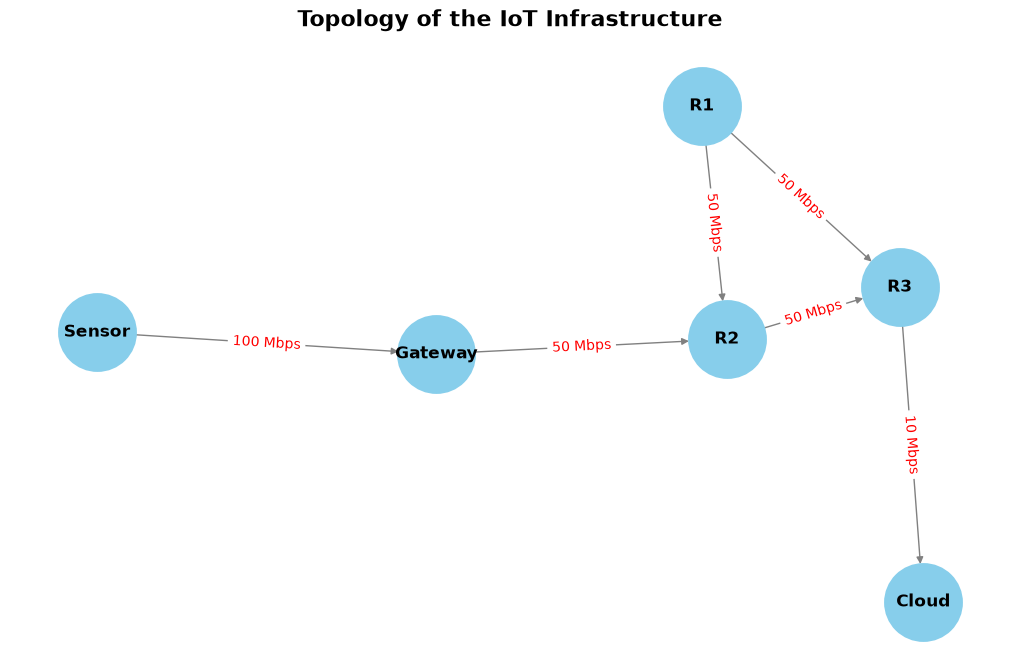

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

pos_base = nx.kamada_kawai_layout(infra)
pos = nx.spring_layout(infra, pos=pos_base, k=1.0, iterations=50, seed=42)

nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=3000,
    font_size=12,
    font_weight='bold',
    edge_color='gray',
    linewidths=2
)

edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of the IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.show()

In [ ]:
import pandas as pd
import json
import os
# Load the JSONL file and extract metrics
json_path = "./results-20260511_160749/json/application.jsonl"
records = []

if not os.path.exists(json_path):
    raise FileNotFoundError(f"File {json_path} not found")

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

if not records:
    raise ValueError("The JSONL file is empty or does not contain valid metrics.")

df_raw = pd.DataFrame(records)

# Extract Step, Packet_ID, Hop_ID and Field from the metric naming convention
extracted = df_raw['metric'].str.extract(r'step_(\d+)_pkt_(\d+)_hop_(\d+)_(.*)')

df_raw['Step'] = extracted[0].astype(float)
df_raw['Packet_ID'] = extracted[1].astype(float)
df_raw['Hop_ID'] = extracted[2].astype(float)
df_raw['Field'] = extracted[3]

# Filter the DataFrame to keep only rows that have valid Packet_IDs (i.e., those that match the expected pattern)
df_hops = df_raw.dropna(subset=['Packet_ID']).copy()

# Convert the relevant columns to integers
df_hops['Step'] = df_hops['Step'].astype(int)
df_hops['Packet_ID'] = df_hops['Packet_ID'].astype(int)
df_hops['Hop_ID'] = df_hops['Hop_ID'].astype(int)

# Group by Step, Packet_ID, and Hop_ID
df_pivot = df_hops.pivot_table(
    index=['Step', 'Packet_ID', 'Hop_ID'],
    columns='Field',
    values='val',
    aggfunc='first'
).reset_index()

# Conversion into numeric types for the relevant columns
numeric_cols = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col], errors='coerce')

df_pivot['queue_length'] = pd.to_numeric(df_pivot.get('queue_length', 0)).fillna(0).astype(int)

# management of 'dropped' field
if 'dropped' in df_pivot.columns:
    # Substitutes NaN values with False (in case there are old records without the field)
    df_pivot['dropped'] = df_pivot['dropped'].fillna(False)
    # Ensures conversion to boolean (in the JSON, Pandas might read it as the string "True")
    df_pivot['dropped'] = df_pivot['dropped'].apply(
        lambda x: str(x).lower() == 'true' if isinstance(x, str) else bool(x)
    )
else:
    df_pivot['dropped'] = False
# -------------------------------------------------------------

# Security check: if the 'hop' string is not in the JSON due to ECLYPSE limitations, add a default value
if 'hop' not in df_pivot.columns:
    df_pivot['hop'] = "Route N/A"

# Print the chronological log of hops
print("\n--- Chronological Log of Hops ---")

# Order by the absolute arrival timestamp
df_log = df_pivot.sort_values('arrival_at_next').dropna(subset=['arrival_at_next'])

for _, row in df_log.iterrows():
    # Extract the route name from the 'hop' field, which is expected to be a string like "Sensor->Gateway"
    route_name = str(row['hop'])

    drop_alert = " ⚠️ [DROPPED]" if row['dropped'] else ""

    print(f"[Arrival: {row['arrival_at_next']:7.4f} ms] | "
          f"Step: {row['Step']:<3} | "
          f"Pkt: {row['Packet_ID']:<3} (Hop {row['Hop_ID']}) | "
          f"Route: {route_name:<15} | "
          f"Queue: {row['queue_length']:>2} pkt | "
          f"Delay Queue: {row['queue_ms']:6.4f} ms{drop_alert}")


--- Chronological Log of Hops ---
[Arrival:  0.8250 ms] | Step: 1   | Pkt: 1   (Hop 1) | Route: Sensor->Gateway | Queue:  0 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.9450 ms] | Step: 1   | Pkt: 2   (Hop 1) | Route: Sensor->Gateway | Queue:  1 pkt | Delay Queue: 0.1200 ms
[Arrival:  1.0650 ms] | Step: 1   | Pkt: 3   (Hop 1) | Route: Sensor->Gateway | Queue:  2 pkt | Delay Queue: 0.2400 ms
[Arrival:  1.1850 ms] | Step: 1   | Pkt: 4   (Hop 1) | Route: Sensor->Gateway | Queue:  3 pkt | Delay Queue: 0.3600 ms
[Arrival:  1.3250 ms] | Step: 2   | Pkt: 5   (Hop 1) | Route: Sensor->Gateway | Queue:  0 pkt | Delay Queue: 0.0000 ms
[Arrival:  1.3450 ms] | Step: 2   | Pkt: 1   (Hop 2) | Route: Gateway->R1     | Queue:  0 pkt | Delay Queue: 0.0000 ms
[Arrival:  1.4650 ms] | Step: 2   | Pkt: 2   (Hop 2) | Route: Gateway->R1     | Queue:  1 pkt | Delay Queue: 0.1200 ms
[Arrival:  1.5850 ms] | Step: 2   | Pkt: 3   (Hop 2) | Route: Gateway->R1     | Queue:  2 pkt | Delay Queue: 0.2400 ms
[Arrival:  1.